# 09 — Matriz extendida de asociaciones

**Proposito.** Extender la matriz de correlaciones y asociaciones del EDA descriptivo previo (5 variables
continuas y 2 tablas de contingencia) a todas las variables incorporadas por este ejercicio, y ordenar
el resultado por tamano de efecto. La tabla ordenada es el insumo `[B-OE3-insumo]`: identifica que
variables muestran asociacion relevante con el desempeno y por tanto **serian** candidatas predictoras
en un ejercicio de modelado posterior. Este cuaderno no entrena ningun modelo ni reporta metrica alguna
de clasificacion.

**Insumo.** `data/universo_extendido.parquet` (notebook 01) y `data/sobrecosto_referencias.parquet`
(notebook 05).

**Etiquetas de objetivo que atiende:** `[A-OE04]`, `[B-OE2]` (correlaciones y variables criticas),
`[B-OE3-insumo]`, `[A-H1]`, `[A-H2]`.

**Rigor declarado.** Alfa a priori de 0.05. Todas las variables continuas presentan asimetria severa
(se verifica en la seccion 1), de modo que se usa Spearman y no Pearson. Cada coeficiente se reporta con
su N efectivo. Con N del orden de las decenas de miles, la significancia estadistica es casi automatica:
la lectura correcta es el tamano de efecto, no el p-valor.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
extra = pd.read_parquet(DIR_DATA / "sobrecosto_referencias.parquet")
df = df.merge(extra, on="id_contrato", how="left")
obs = df[df["observable"]].copy()
df["licitacion_publica"] = es_licitacion_publica(df["modalidad_de_contratacion"])
obs["licitacion_publica"] = es_licitacion_publica(obs["modalidad_de_contratacion"])
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")

Universo: 48,331 | Observable: 19,194


## 1. Verificacion de supuestos antes de elegir el coeficiente

In [3]:
marcar("supuestos")

CONTINUAS = [
    "valor_del_contrato", "valor_pagado", "precio_base", "valor_adjudicado_proceso",
    "plazo_pactado_dias", "plazo_contractual_final_dias", "deslizamiento_plazo_dias",
    "desviacion_costo_pct", "sobrecosto_vs_precio_base_pct", "n_oferentes", "n_invitados",
    "n_visualizaciones", "n_modificaciones_total", "dias_adicionados",
    "antiguedad_proveedor_anios", "anio_firma",
]
sup = pd.DataFrame({
    "variable": CONTINUAS,
    "N_efectivo": [int(obs[c].notna().sum()) for c in CONTINUAS],
    "skew": [round(obs[c].skew(), 2) for c in CONTINUAS],
    "curtosis": [round(obs[c].kurtosis(), 2) for c in CONTINUAS],
    "mediana": [obs[c].median() for c in CONTINUAS],
})
sup["asimetria_severa"] = np.where(sup["skew"].abs() > 1, "SI", "no")
print(sup.to_string(index=False))
print()
n_sev = int((sup["skew"].abs() > 1).sum())
print(f"{n_sev} de {len(CONTINUAS)} variables continuas superan |skew| = 1.")
print("Decision metodologica: se usa correlacion de Spearman (rangos) en toda la matriz. Se descarta")
print("Pearson por incumplimiento del supuesto de normalidad, verificado y no asumido.")

                     variable  N_efectivo     skew    curtosis          mediana asimetria_severa
           valor_del_contrato       19194  20.1300    534.1400 268,794,495.0000               SI
                 valor_pagado       19194  17.2000    446.7300           0.0000               SI
                  precio_base       19177 102.9300 12,460.0200 260,000,000.0000               SI
     valor_adjudicado_proceso       19177 130.9100 17,659.6700 136,724,710.0000               SI
           plazo_pactado_dias       16326  34.6400  1,711.6200         115.0000               SI
 plazo_contractual_final_dias       19194   3.8000     36.9200         136.0000               SI
     deslizamiento_plazo_dias       16326 -36.4700  1,772.1700           2.0000               SI
         desviacion_costo_pct        8681  -2.7700      7.3300           0.0000               SI
sobrecosto_vs_precio_base_pct       19065  58.9000  3,585.3500           0.0000               SI
                  n_oferentes 

## 2. Matriz de Spearman extendida

In [4]:
marcar("spearman_matriz")

VARS_MATRIZ = ["valor_del_contrato", "precio_base", "plazo_pactado_dias",
               "plazo_contractual_final_dias", "deslizamiento_plazo_dias", "desviacion_costo_pct",
               "sobrecosto_vs_precio_base_pct", "n_oferentes", "n_invitados", "n_visualizaciones",
               "n_modificaciones_total", "dias_adicionados", "anio_firma"]
ETQ = ["Valor contrato", "Precio base", "Plazo pactado", "Plazo final", "Deslizamiento",
       "Desv. costo", "Sobrecosto vs PB", "Oferentes", "Invitados", "Visualizaciones",
       "Modificaciones", "Dias adicionados", "Anio firma"]

M_obs = obs[VARS_MATRIZ].corr(method="spearman").round(3)
M_uni = df[VARS_MATRIZ].corr(method="spearman").round(3)
M_obs.index = M_obs.columns = ETQ
M_uni.index = M_uni.columns = ETQ
M_obs.to_csv(DIR_DATA / "spearman_matriz_observable.csv")
M_uni.to_csv(DIR_DATA / "spearman_matriz_universo.csv")
print("Matriz de Spearman — subconjunto observable:")
print(M_obs.to_string())

Matriz de Spearman — subconjunto observable:
                  Valor contrato  Precio base  Plazo pactado  Plazo final  Deslizamiento  Desv. costo  Sobrecosto vs PB  Oferentes  Invitados  Visualizaciones  Modificaciones  Dias adicionados  Anio firma
Valor contrato            1.0000       0.9690         0.6040       0.6570         0.3790      -0.3590            0.1670     0.2520     0.0350           0.4600          0.5060            0.2530     -0.0490
Precio base               0.9690       1.0000         0.5980       0.6470         0.3690      -0.3510            0.0320     0.2880     0.0160           0.4660          0.4790            0.2380     -0.0640
Plazo pactado             0.6040       0.5980         1.0000       0.8770         0.3000      -0.2400            0.1830     0.0250    -0.1110           0.1010          0.3590            0.2910     -0.1640
Plazo final               0.6570       0.6470         0.8770       1.0000         0.6310      -0.2740            0.1700     0.0560    -

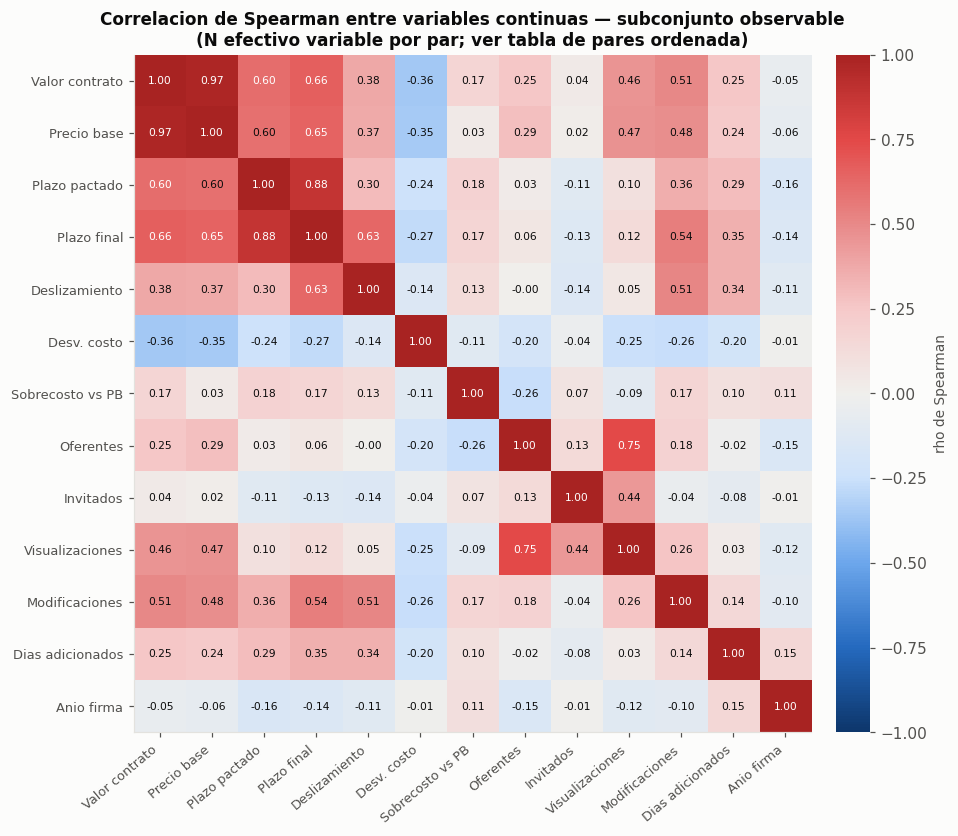

Figura persistida: 09_matriz_spearman_extendida.png


In [5]:
marcar("fig_matriz")

fig, ax = plt.subplots(figsize=(9.6, 8))
im = ax.imshow(M_obs.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(ETQ))); ax.set_xticklabels(ETQ, rotation=40, ha="right", fontsize=8.5)
ax.set_yticks(range(len(ETQ))); ax.set_yticklabels(ETQ, fontsize=8.5)
for i in range(len(ETQ)):
    for j in range(len(ETQ)):
        v = M_obs.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="#ffffff" if abs(v) > 0.6 else TEXT_1)
ax.set_title("Correlacion de Spearman entre variables continuas — subconjunto observable\n"
             "(N efectivo variable por par; ver tabla de pares ordenada)", fontsize=11)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label("rho de Spearman", fontsize=9); cb.outline.set_visible(False)
guardar_mostrar(fig, "09_matriz_spearman_extendida.png")

## 3. Pares continuos ordenados por tamano de efecto

In [6]:
marcar("pares_ordenados")

OBJETIVOS = ["deslizamiento_plazo_dias", "desviacion_costo_pct", "sobrecosto_vs_precio_base_pct",
             "n_modificaciones_total"]
PREDICTORAS = ["valor_del_contrato", "precio_base", "plazo_pactado_dias", "plazo_contractual_final_dias",
               "n_oferentes", "n_invitados", "n_visualizaciones", "antiguedad_proveedor_anios",
               "anio_firma", "n_contratos_del_portafolio"]

filas = []
for obj in OBJETIVOS:
    for pre in PREDICTORAS:
        if obj == pre:
            continue
        for etq, x in [("universo_completo", df), ("observable", obs)]:
            s = spearman(x[pre], x[obj])
            filas.append({"indicador_de_desempeno": obj, "variable": pre, "lectura": etq,
                          "rho": round(s["rho"], 4), "p": fmt_p(s["p"]),
                          "N_efectivo": s["n_efectivo"], "tamano_efecto": s["efecto"],
                          "abs_rho": abs(round(s["rho"], 4))})
pares = pd.DataFrame(filas).sort_values("abs_rho", ascending=False).reset_index(drop=True)
pares.to_csv(DIR_DATA / "pares_spearman_ordenados.csv", index=False)
print("Top 20 pares por magnitud del coeficiente (ambas lecturas):")
print(pares.head(20).drop(columns="abs_rho").to_string(index=False))

Top 20 pares por magnitud del coeficiente (ambas lecturas):
       indicador_de_desempeno                     variable           lectura     rho         p  N_efectivo tamano_efecto
     deslizamiento_plazo_dias plazo_contractual_final_dias        observable  0.6307  < 1e-300       16326        grande
     deslizamiento_plazo_dias plazo_contractual_final_dias universo_completo  0.6118  < 1e-300       37155        grande
       n_modificaciones_total plazo_contractual_final_dias        observable  0.5408  < 1e-300       19194        grande
       n_modificaciones_total           valor_del_contrato        observable  0.5055  < 1e-300       19194        grande
       n_modificaciones_total                  precio_base        observable  0.4795  < 1e-300       19177       mediano
       n_modificaciones_total plazo_contractual_final_dias universo_completo  0.4678  < 1e-300       42252       mediano
     deslizamiento_plazo_dias           valor_del_contrato        observable  0.3794  < 1e-30

**Advertencia sobre relaciones definicionales.** Tres pares de la tabla anterior no son hallazgos
sustantivos sino consecuencias de como se construyen los indicadores: `plazo_contractual_final_dias`
frente a `deslizamiento_plazo_dias` (el segundo se calcula restando el plazo pactado al primero),
`dias_adicionados` frente a `deslizamiento_plazo_dias` (SECOP actualiza la fecha de fin al registrar la
prorroga, notebook 03) y `valor_pagado` frente a `desviacion_costo_pct`. Se dejan en la matriz por
completitud pero no deben leerse como asociacion empirica.

## 4. Asociaciones entre variables categoricas y desempeno

In [7]:
marcar("categoricas")

CATEGORICAS = ["modalidad_de_contratacion", "tipo_contratista", "es_pyme", "rango_cuantia",
               "competencia_cat", "plazo_discretizado", "orden", "departamento",
               "prov_tipo_empresa", "origen_de_los_recursos", "entidad_centralizada"]

def bandera_retraso(x):
    return np.where(x["deslizamiento_plazo_dias"].isna(), np.nan,
                    (x["deslizamiento_plazo_dias"] > 30).astype(float))

filas = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    y = x.copy()
    y["retraso_material"] = bandera_retraso(y)
    for cat in CATEGORICAS:
        if cat not in y.columns:
            continue
        # contra el indice de alcance (cobertura completa)
        sub = y[y[cat].notna()]
        if sub[cat].nunique() < 2:
            continue
        tab = pd.crosstab(sub[cat], sub["indice_alcance"])
        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue
        r = cramers_v(tab)
        filas.append({"variable_categorica": cat, "objetivo": "indice_alcance", "lectura": etq,
                      "chi2": round(r["chi2"], 2), "gl": r["gl"], "p": fmt_p(r["p"]),
                      "V_cramer": round(r["V_cramer"], 4), "tamano_efecto": r["efecto"],
                      "N_efectivo": r["n_efectivo"],
                      "min_frecuencia_esperada": round(r["min_esperada"], 1)})
        # contra la bandera de retraso material
        sub2 = y[y[cat].notna() & y["retraso_material"].notna()]
        if sub2[cat].nunique() < 2:
            continue
        tab2 = pd.crosstab(sub2[cat], sub2["retraso_material"])
        if tab2.shape[0] < 2 or tab2.shape[1] < 2:
            continue
        r2 = cramers_v(tab2)
        filas.append({"variable_categorica": cat, "objetivo": "retraso_material_mayor_30d",
                      "lectura": etq, "chi2": round(r2["chi2"], 2), "gl": r2["gl"],
                      "p": fmt_p(r2["p"]), "V_cramer": round(r2["V_cramer"], 4),
                      "tamano_efecto": r2["efecto"], "N_efectivo": r2["n_efectivo"],
                      "min_frecuencia_esperada": round(r2["min_esperada"], 1)})

asoc = pd.DataFrame(filas).sort_values("V_cramer", ascending=False).reset_index(drop=True)
asoc.to_csv(DIR_DATA / "asociaciones_categoricas.csv", index=False)
print("Asociaciones categoricas ordenadas por V de Cramer (todas las lecturas):")
print(asoc.to_string(index=False))

Asociaciones categoricas ordenadas por V de Cramer (todas las lecturas):
      variable_categorica                   objetivo           lectura       chi2  gl         p  V_cramer       tamano_efecto  N_efectivo  min_frecuencia_esperada
            rango_cuantia retraso_material_mayor_30d        observable 2,011.6700   4  < 1e-300    0.3510            moderado       16326                 242.8000
modalidad_de_contratacion retraso_material_mayor_30d        observable 2,009.5700   8  < 1e-300    0.3508            moderado       16326                  18.1000
            rango_cuantia retraso_material_mayor_30d universo_completo 4,211.1100   4  < 1e-300    0.3370            moderado       37077                 421.4000
modalidad_de_contratacion retraso_material_mayor_30d universo_completo 3,313.8700   8  < 1e-300    0.2986      debil-moderado       37155                  26.9000
       plazo_discretizado retraso_material_mayor_30d        observable 1,308.6800   5 8.41e-281    0.2831      d

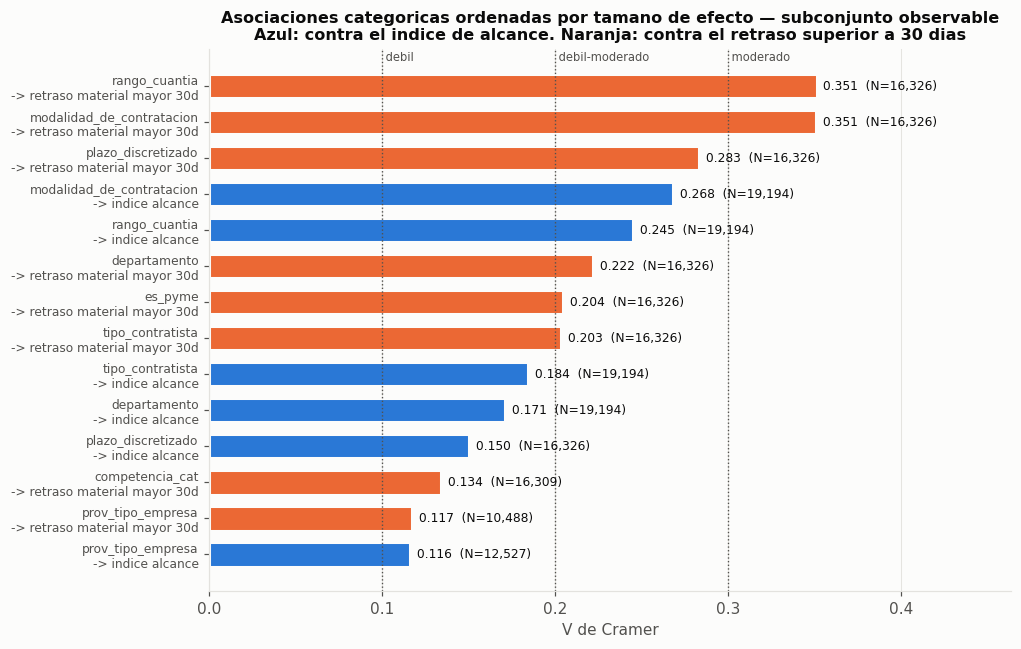

Figura persistida: 09_asociaciones_categoricas.png


In [8]:
marcar("fig_cramer")

top = (asoc[asoc["lectura"] == "observable"]
       .sort_values("V_cramer", ascending=True).tail(14))
etiquetas = [f"{r.variable_categorica}\n-> {r.objetivo.replace('_', ' ')}" for r in top.itertuples()]
colores = [PALETA[0] if r.objetivo == "indice_alcance" else PALETA[1] for r in top.itertuples()]

fig, ax = plt.subplots(figsize=(9.4, 6.4))
ax.barh(range(len(top)), top["V_cramer"], color=colores, height=0.68,
        edgecolor=SURFACE, linewidth=2)
for i, (v, n) in enumerate(zip(top["V_cramer"], top["N_efectivo"])):
    ax.text(v + 0.004, i, f"{v:.3f}  (N={n:,})", va="center", fontsize=8, color=TEXT_1)
ax.set_yticks(range(len(top))); ax.set_yticklabels(etiquetas, fontsize=8)
ax.set_xlabel("V de Cramer")
ax.set_xlim(0, top["V_cramer"].max() * 1.32)
ax.set_title("Asociaciones categoricas ordenadas por tamano de efecto — subconjunto observable\n"
             "Azul: contra el indice de alcance. Naranja: contra el retraso superior a 30 dias",
             fontsize=10.5)
ax.yaxis.grid(False); ax.set_axisbelow(True)
for umbral, nombre in [(0.1, "debil"), (0.2, "debil-moderado"), (0.3, "moderado")]:
    if umbral < ax.get_xlim()[1]:
        ax.axvline(umbral, color=TEXT_2, lw=0.9, ls=":")
        ax.text(umbral, len(top) - 0.3, f" {nombre}", fontsize=7.5, color=TEXT_2)
guardar_mostrar(fig, "09_asociaciones_categoricas.png")

## 5. Tabla consolidada de variables con asociacion relevante

La tabla siguiente es el insumo `[B-OE3-insumo]`. Enumera las variables que muestran asociacion no
trivial con alguna dimension del desempeno y clasifica cada una segun **cuando** esta disponible en el
ciclo del contrato. Esa distincion es la que hace utilizable o no una variable en un ejercicio
predictivo posterior: una variable que solo existe una vez ocurrida la modificacion no puede anticiparla.
Este cuaderno se limita a senalar la distincion; no construye ningun modelo.

In [9]:
marcar("insumo_b")

insumo = pd.DataFrame([
    ("valor_del_contrato", "continua", "En la firma", "Deslizamiento, alcance, modificaciones",
     "Gradiente monotono de retraso por cuantia (notebook 05)"),
    ("precio_base", "continua", "Antes de la adjudicacion", "Sobrecosto sobre el presupuesto oficial",
     "Referencia inicial que resuelve N-K05 (notebook 05)"),
    ("plazo_pactado_dias", "continua", "En la firma", "Deslizamiento, extension",
     "Gradiente monotono de extension por duracion (notebook 08)"),
    ("n_oferentes", "continua", "En la adjudicacion", "Desviacion de costo",
     "Efecto pequeno en costo, nulo en tiempo (notebook 04)"),
    ("n_invitados", "continua", "Antes de la adjudicacion", "Deslizamiento, costo",
     "Ver tabla de pares ordenada"),
    ("n_visualizaciones", "continua", "Antes de la adjudicacion", "Deslizamiento, costo",
     "Medida de exposicion del proceso, no de competencia efectiva"),
    ("modalidad_de_contratacion", "categorica", "En la firma", "Alcance, retraso material",
     "Mayor V de Cramer del bloque categorico"),
    ("tipo_contratista", "categorica", "En la firma", "Alcance, modificaciones",
     "Eje de A-H2 (notebooks 07 y 10)"),
    ("es_pyme", "categorica", "En la firma", "Deslizamiento, alcance",
     "Cobertura del 100%, sin usar hasta este EDA (notebook 07)"),
    ("rango_cuantia", "categorica", "En la firma", "Retraso material, alcance",
     "Variable de control obligatoria por confusion con la modalidad"),
    ("departamento", "categorica", "En la firma", "Deslizamiento, alcance",
     "Dominado por un solo departamento (notebook 10)"),
    ("anio_firma", "continua", "En la firma", "Todos los indicadores",
     "Los indicadores no son estables en el tiempo (notebook 06)"),
    ("reincidencia del contratista", "derivada", "En la firma", "Retraso material, alcance",
     "Derivable del propio historico sin fuentes externas (notebook 07)"),
    ("n_modificaciones_total", "continua", "Durante la ejecucion", "Deslizamiento",
     "NO anticipatoria: coincide en parte con el propio indicador de tiempo (notebook 08)"),
    ("dias_adicionados", "continua", "Durante la ejecucion", "Deslizamiento",
     "NO anticipatoria por la misma razon"),
    ("valor_pagado", "continua", "Al cierre", "Desviacion de costo",
     "NO anticipatoria: define el indicador de costo"),
], columns=["variable", "tipo", "disponible_en", "asociada_con", "observacion"])
insumo.to_csv(DIR_DATA / "insumo_variables_candidatas.csv", index=False)
print("Variables disponibles ANTES o EN la firma (utilizables de forma anticipatoria):",
      int((~insumo["disponible_en"].isin(["Durante la ejecucion", "Al cierre"])).sum()))
print("Variables solo disponibles durante o despues de la ejecucion (no anticipatorias):",
      int(insumo["disponible_en"].isin(["Durante la ejecucion", "Al cierre"]).sum()))
insumo

Variables disponibles ANTES o EN la firma (utilizables de forma anticipatoria): 13
Variables solo disponibles durante o despues de la ejecucion (no anticipatorias): 3


,variable,tipo,disponible_en,asociada_con,observacion
0,valor_del_contrato,continua,En la firma,"Deslizamiento, alcance, modificaciones",Gradiente monotono de retraso por cuantia (not...
1,precio_base,continua,Antes de la adjudicacion,Sobrecosto sobre el presupuesto oficial,Referencia inicial que resuelve N-K05 (noteboo...
2,plazo_pactado_dias,continua,En la firma,"Deslizamiento, extension",Gradiente monotono de extension por duracion (...
3,n_oferentes,continua,En la adjudicacion,Desviacion de costo,"Efecto pequeno en costo, nulo en tiempo (noteb..."
4,n_invitados,continua,Antes de la adjudicacion,"Deslizamiento, costo",Ver tabla de pares ordenada
5,n_visualizaciones,continua,Antes de la adjudicacion,"Deslizamiento, costo","Medida de exposicion del proceso, no de compet..."
6,modalidad_de_contratacion,categorica,En la firma,"Alcance, retraso material",Mayor V de Cramer del bloque categorico
7,tipo_contratista,categorica,En la firma,"Alcance, modificaciones",Eje de A-H2 (notebooks 07 y 10)
8,es_pyme,categorica,En la firma,"Deslizamiento, alcance","Cobertura del 100%, sin usar hasta este EDA (n..."
9,rango_cuantia,categorica,En la firma,"Retraso material, alcance",Variable de control obligatoria por confusion ...


## 6. Sintesis de hallazgos etiquetados

In [10]:
reg = RegistroHallazgos("09")
mejor_cat = asoc[asoc["lectura"] == "observable"].iloc[0]
reg.add("H09-01",
        f"La variable categorica con mayor asociacion al desempeno es `{mejor_cat['variable_categorica']}` frente a {mejor_cat['objetivo']}",
        f"V de Cramer = {mejor_cat['V_cramer']}, N efectivo = {mejor_cat['N_efectivo']:,}, {mejor_cat['tamano_efecto']}",
        ref("categoricas"), ["B-OE2", "B-OE3-insumo", "A-OE04"], "Alto",
        "Extiende a 11 variables la matriz de dos tablas de contingencia del EDA previo")
reg.add("H09-02",
        "Todas las variables continuas del analisis presentan asimetria severa, lo que descarta Pearson por verificacion y no por supuesto",
        f"{n_sev} de {len(CONTINUAS)} variables con |skew| > 1", ref("supuestos"),
        ["A-OE03"], "Medio",
        "El criterio de eleccion de la prueba queda documentado y es auditable")
max_hierro = pares[(pares["lectura"] == "observable")
                   & pares["indicador_de_desempeno"].isin(
                       ["deslizamiento_plazo_dias", "desviacion_costo_pct", "sobrecosto_vs_precio_base_pct"])
                   & (pares["variable"] != "plazo_contractual_final_dias")].iloc[0]
reg.add("H09-03",
        "Frente a los tres indicadores de la restriccion de hierro ninguna variable anticipatoria supera el tamano de efecto mediano; solo el numero de modificaciones alcanza efecto grande con la cuantia",
        f"maximo |rho| anticipatorio: {max_hierro['variable']} ~ {max_hierro['indicador_de_desempeno']} = {max_hierro['rho']} ({max_hierro['tamano_efecto']}, N efectivo {max_hierro['N_efectivo']:,})",
        ref("pares_ordenados"), ["B-OE2", "B-OE3-insumo"], "Alto",
        "Resultado honesto: las asociaciones anticipatorias son de magnitud pequena a mediana. Se excluye del calculo el plazo contractual final por relacion definicional con el deslizamiento")
reg.add("H09-04",
        "Las variables con mayor asociacion al desempeno son mayoritariamente NO anticipatorias: se conocen durante o despues de la ejecucion",
        "Tabla de variables candidatas con su momento de disponibilidad", ref("insumo_b"),
        ["B-OE3-insumo", "CALIDAD"], "Alto",
        "Distincion imprescindible antes de usar cualquiera de estas variables en un ejercicio predictivo")
reg.add("H09-05",
        "El sobrecosto sobre el precio base se comporta como un indicador distinto de la desviacion de costo previa, con su propio patron de asociaciones",
        "Fila correspondiente en la matriz de Spearman extendida", ref("spearman_matriz"),
        ["A-OE03", "B-OE2"], "Alto",
        "Confirma que la redefinicion del notebook 05 aporta informacion y no replica la medicion anterior")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H09-01,09,c008,La variable categorica con mayor asociacion al...,"V de Cramer = 0.351, N efectivo = 16,326, mode...",[B-OE2] [B-OE3-insumo] [A-OE04],Alto,Extiende a 11 variables la matriz de dos tabla...
1,H09-02,09,c004,Todas las variables continuas del analisis pre...,14 de 16 variables con |skew| > 1,[A-OE03],Medio,El criterio de eleccion de la prueba queda doc...
2,H09-03,09,c007,Frente a los tres indicadores de la restriccio...,maximo |rho| anticipatorio: valor_del_contrato...,[B-OE2] [B-OE3-insumo],Alto,Resultado honesto: las asociaciones anticipato...
3,H09-04,09,c010,Las variables con mayor asociacion al desempen...,Tabla de variables candidatas con su momento d...,[B-OE3-insumo] [CALIDAD],Alto,Distincion imprescindible antes de usar cualqu...
4,H09-05,09,c005,El sobrecosto sobre el precio base se comporta...,Fila correspondiente en la matriz de Spearman ...,[A-OE03] [B-OE2],Alto,Confirma que la redefinicion del notebook 05 a...


## Sintesis del notebook 09

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H09-01 | La variable categorica de mayor asociacion al desempeno se identifica con V de Cramer y N efectivo | `[B-OE2]` `[B-OE3-insumo]` `[A-OE04]` |
| H09-02 | Toda la matriz usa Spearman por asimetria verificada, no por supuesto | `[A-OE03]` |
| H09-03 | Ninguna variable anticipatoria supera el efecto mediano frente a la restriccion de hierro | `[B-OE2]` `[B-OE3-insumo]` |
| H09-04 | Las variables de mayor asociacion son mayoritariamente no anticipatorias | `[B-OE3-insumo]` `[CALIDAD]` |
| H09-05 | El sobrecosto sobre precio base es un indicador distinto y no redundante | `[A-OE03]` `[B-OE2]` |

**Productos persistidos:** `data/spearman_matriz_observable.csv`, `data/spearman_matriz_universo.csv`,
`data/pares_spearman_ordenados.csv`, `data/asociaciones_categoricas.csv`,
`data/insumo_variables_candidatas.csv`, `figuras/09_matriz_spearman_extendida.png`,
`figuras/09_asociaciones_categoricas.png`.

**Declaracion de alcance.** La tabla de variables candidatas es informacion sobre asociacion, no un
ejercicio de seleccion de variables ni un modelo. No se importa ninguna libreria de aprendizaje
automatico en este cuaderno ni en ningun otro de este EDA, y no se reporta ninguna metrica de
clasificacion.